# ML Zoomcamp 2026 - Homework 2: Machine Learning for Regression

Goal: build a linear regression model that predicts `fuel_efficiency_mpg`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load the data

Same 2026 dataset as homework 1.

In [2]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df_full = pd.read_csv(url)
df_full.shape

(10000, 11)

## Prepare the dataset

Keep only the 4 features we will use plus the target.

In [3]:
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_full[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA: does `fuel_efficiency_mpg` have a long tail?

A long tail means a few extreme values stretched far to one side of the histogram. If the target had one (like car prices in the lecture), we would apply `np.log1p` to it.

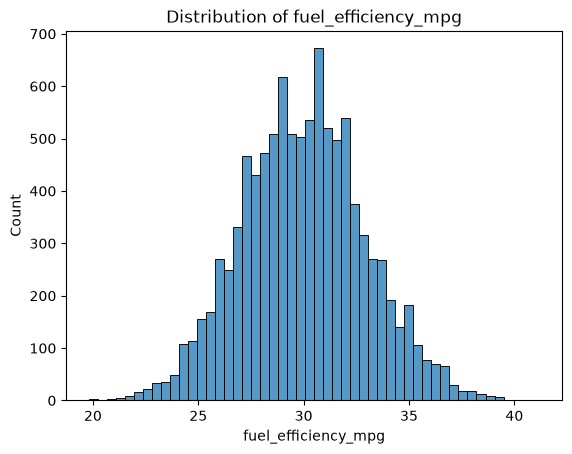

In [4]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.title('Distribution of fuel_efficiency_mpg')
plt.show()

In [5]:
df['fuel_efficiency_mpg'].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

The distribution is roughly symmetric (bell-shaped), with mean and median close to each other. No long tail, so we keep the target as it is, without a log transform.

## Q1. Column with missing values

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2. Median of `horsepower`

`median()` ignores NaN, so it is computed on the non-missing values.

In [7]:
df['horsepower'].median()

np.float64(254.0)

## Helper functions (from the lectures)

- `prepare_split`: shuffle with a seed and split 60/20/20 (exactly as in the lecture).
- `train_linear_regression`: normal equation `w = (XᵀX)⁻¹Xᵀy`, with a column of ones for the bias `w0`.
- `train_linear_regression_reg`: same, but adds `r` to the diagonal of `XᵀX` (regularization).
- `rmse`: root mean squared error, the evaluation metric.
- `prepare_X`: select the features and fill NaN with a given value.

In [8]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']


def prepare_split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)
    return df_train, df_val, df_test


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


def prepare_X(df, fill_value):
    df_num = df[features].fillna(fill_value)
    return df_num.values

## Split with seed 42

Note: `fuel_efficiency_mpg` must not be inside `X`, so we pull it out as `y`.

In [9]:
df_train, df_val, df_test = prepare_split(df, 42)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Q3. Fill with 0 vs fill with the mean

The mean is computed **on the training set only**. Using validation data to compute it would leak information the model should not see.

In [ ]:

X_train = prepare_X(df_train, 0)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, 0)
y_pred = w0 + X_val.dot(w)
score_zero = round(rmse(y_val, y_pred), 3)
score_zero

np.float64(2.205)

In [11]:
# Option 2: fill with the mean of the TRAINING set
hp_mean = df_train['horsepower'].mean()
print('train mean horsepower:', hp_mean)

X_train = prepare_X(df_train, hp_mean)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, hp_mean)
y_pred = w0 + X_val.dot(w)
score_mean = round(rmse(y_val, y_pred), 3)
score_mean

train mean horsepower: 254.46338337605272


np.float64(2.202)

In [12]:
print('With 0:   ', score_zero)
print('With mean:', score_mean)

With 0:    2.205
With mean: 2.202


## Q4. Regularization

Fill NaN with 0 and try several values of `r`. A larger `r` pushes the weights toward smaller values. RMSE rounded to 4 digits; on a tie, choose the smallest `r`.

In [13]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

scores_r = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    scores_r[r] = round(rmse(y_val, y_pred), 4)
    print(r, scores_r[r])

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [14]:
best_score = min(scores_r.values())
best_r = min(r for r, s in scores_r.items() if s == best_score)
best_r, best_score

(0, np.float64(2.2053))

## Q5. How much does the seed matter?

For each seed: split, fill with 0, train without regularization, evaluate on validation. A low standard deviation means the model is stable regardless of the split.

In [15]:
scores_seed = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train_s, df_val_s, _ = prepare_split(df, seed)
    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values

    X_train_s = prepare_X(df_train_s, 0)
    X_val_s = prepare_X(df_val_s, 0)

    w0, w = train_linear_regression(X_train_s, y_train_s)
    y_pred = w0 + X_val_s.dot(w)
    score = rmse(y_val_s, y_pred)
    scores_seed.append(score)
    print(seed, round(score, 4))

0 2.2392
1 2.2021
2 2.1634
3 2.2044
4 2.2019
5 2.2458
6 2.2697
7 2.1908
8 2.2166
9 2.207


In [16]:
round(np.std(scores_seed), 3)

np.float64(0.029)

## Q6. Final model on the test set

Split with seed 9, combine train + validation into one bigger training set (as in lesson 1.5), fill with 0, train with `r=0.001` and evaluate **once** on the test set.

In [17]:
df_train9, df_val9, df_test9 = prepare_split(df, 9)
df_full_train = pd.concat([df_train9, df_val9]).reset_index(drop=True)

X_full_train = prepare_X(df_full_train, 0)
y_full_train = df_full_train['fuel_efficiency_mpg'].values

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test9 = prepare_X(df_test9, 0)
y_test9 = df_test9['fuel_efficiency_mpg'].values
y_pred = w0 + X_test9.dot(w)

round(rmse(y_test9, y_pred), 3)

np.float64(2.236)